# Harrison et al. (2009): Rapamycin Lifespan Reproduction

A compact reproduction of the main survival-analysis results from:

> Harrison DE et al. *Rapamycin fed late in life extends lifespan in genetically heterogeneous mice.* Nature 460, 392–395 (2009). https://pmc.ncbi.nlm.nih.gov/articles/PMC2786175

The analysis uses the NIA Interventions Testing Program **C2005** cohort and compares `Control` with `Rapa`.

The notebook covers:

1. data validation;
2. censoring;
3. Kaplan–Meier survival curves;
4. median lifespan;
5. age at 90% mortality;
6. pooled log-rank tests;
7. the mechanics of Kaplan–Meier and log-rank;
8. site-specific replication across `TJL`, `UM`, and `UT`;
9. Wang–Allison late-life survival testing;
10. site-stratified Cox proportional hazards models.

## Environment

```bash
uv init harrison-2009-rapamycin-reproduction
cd harrison-2009-rapamycin-reproduction

uv add jupyter pandas openpyxl matplotlib lifelines scipy
uv run jupyter lab
```

Repository layout:

```text
harrison-2009-rapamycin-reproduction/
├── C2005.xlsx
├── analysis.ipynb
├── pyproject.toml
└── uv.lock
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.utils import qth_survival_time
from scipy.stats import fisher_exact

## Data

`C2005.xlsx` is the cohort containing the original late-life rapamycin experiment together with the contemporaneous control and other intervention groups.

https://phenome.jax.org/projects/ITP1

In [2]:
DATA_FILE = Path("ITP_C2005_Lifespan.xlsx")

df = pd.read_excel(DATA_FILE)

df.head()

,population,cohort,site,sex,id,group,dose,age_initiation,status,dead,age
0,UM-HET3,C2005,TJL,f,JL01025,CAPE_hi,300,4.0,dead,1,965
1,UM-HET3,C2005,TJL,f,JL01026,CAPE_hi,300,4.0,dead,1,903
2,UM-HET3,C2005,TJL,f,JL01027,CAPE_hi,300,4.0,dead,1,608
3,UM-HET3,C2005,TJL,f,JL01028,CAPE_hi,300,4.0,dead,1,1203
4,UM-HET3,C2005,TJL,f,JL01093,CAPE_hi,300,4.0,dead,1,1134


## Validate the dataset

The analysis expects the individual-level survival fields used throughout the notebook:

- `sex`: `f` or `m`
- `group`: intervention group
- `age`: age in days at death or censoring
- `dead`: `1` for observed death, `0` for right-censoring
- `site`: ITP test site

In [3]:
REQUIRED_COLUMNS = {"sex", "group", "age", "dead", "site"}

missing_columns = REQUIRED_COLUMNS - set(df.columns)
assert not missing_columns, f"Missing columns: {sorted(missing_columns)}"

assert {"f", "m"} <= set(df["sex"])
assert {"Control", "Rapa"} <= set(df["group"])
assert set(df["dead"]).issubset({0, 1})

df[["sex", "group", "site", "age", "dead"]].head()

,sex,group,site,age,dead
0,f,CAPE_hi,TJL,965,1
1,f,CAPE_hi,TJL,903,1
2,f,CAPE_hi,TJL,608,1
3,f,CAPE_hi,TJL,1203,1
4,f,CAPE_hi,TJL,1134,1


In [4]:
df.groupby(["site", "sex", "group"]).size().rename("n").reset_index()

,site,sex,group,n
0,TJL,f,CAPE_hi,48
1,TJL,f,CAPE_lo,48
2,TJL,f,Control,96
3,TJL,f,Enal,48
4,TJL,f,Rapa,48
5,TJL,m,CAPE_hi,60
6,TJL,m,CAPE_lo,60
7,TJL,m,Control,126
8,TJL,m,Enal,60
9,TJL,m,Rapa,60


## Select the experiment

The other C2005 intervention groups are outside the scope of this reproduction.

In [5]:
study = (
    df.loc[
        df["group"].isin(["Control", "Rapa"]),
        ["sex", "group", "site", "age", "dead"],
    ]
    .copy()
    .sort_values("age")
)

study.groupby(["site", "sex", "group"]).size().rename("n").reset_index()

,site,sex,group,n
0,TJL,f,Control,96
1,TJL,f,Rapa,48
2,TJL,m,Control,126
3,TJL,m,Rapa,60
4,UM,f,Control,96
5,UM,f,Rapa,48
6,UM,m,Control,126
7,UM,m,Rapa,57
8,UT,f,Control,104
9,UT,f,Rapa,48


## Censoring

Survival data are different from an ordinary table of observed lifespans.

```text
age = 900, dead = 1
```

means the mouse died at 900 days.

```text
age = 900, dead = 0
```

means the mouse was observed through 900 days, but its true death time is unknown.

The second mouse must not be treated as if it died at day 900. This is **right-censoring**.

In [6]:
study.groupby(["sex", "group", "dead"]).size().rename("n").reset_index()

,sex,group,dead,n
0,f,Control,0,7
1,f,Control,1,289
2,f,Rapa,0,1
3,f,Rapa,1,143
4,m,Control,0,21
5,m,Control,1,357
6,m,Rapa,0,9
7,m,Rapa,1,168


## Kaplan–Meier estimator

The survival function is

$$
S(t) = P(T > t)
$$

where $T$ is time to death.

At a death time $t_i$:

- $n_i$ animals are still at risk immediately before that time;
- $d_i$ deaths occur at that time.

The conditional probability of surviving that step is

$$
1 - \frac{d_i}{n_i}
$$

Kaplan–Meier multiplies these conditional probabilities:

$$
\hat{S}(t)
=
\prod_{t_i \leq t}
\left(1 - \frac{d_i}{n_i}\right)
$$

Censored animals contribute to the risk set until their censoring time, but are never counted as deaths.

In [7]:
def fit_km(data, label):
    return KaplanMeierFitter().fit(
        durations=data["age"],
        event_observed=data["dead"],
        label=label,
    )

## Pooled survival curves

First reproduce the main comparison with all three sites pooled, separately for females and males.

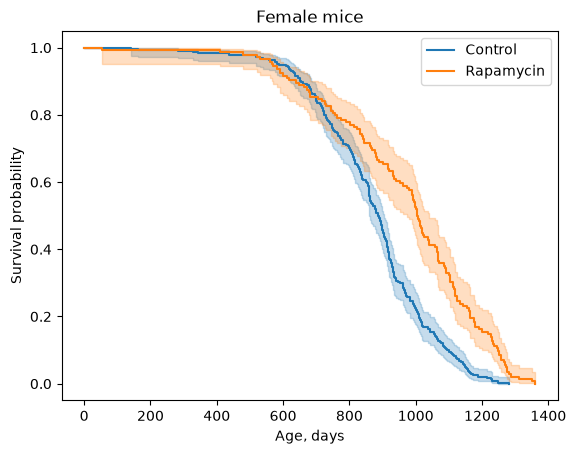

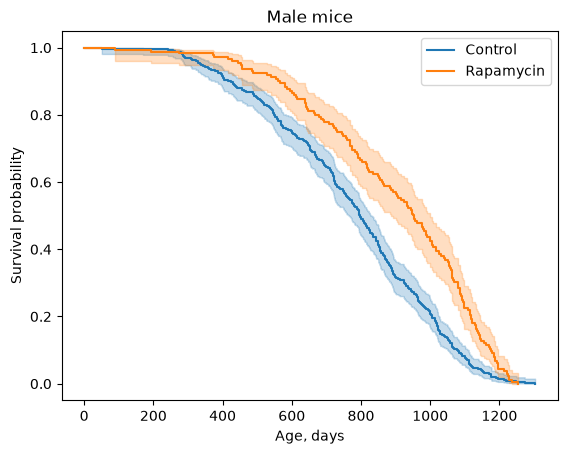

In [8]:
km_models = {}

for sex, sex_label in [("f", "Female"), ("m", "Male")]:
    sex_data = study[study["sex"] == sex]
    control = sex_data[sex_data["group"] == "Control"]
    rapa = sex_data[sex_data["group"] == "Rapa"]

    km_control = fit_km(control, "Control")
    km_rapa = fit_km(rapa, "Rapamycin")

    km_models[(sex, "Control")] = km_control
    km_models[(sex, "Rapa")] = km_rapa

    fig, ax = plt.subplots()
    km_control.plot_survival_function(ax=ax)
    km_rapa.plot_survival_function(ax=ax)

    ax.set(
        title=f"{sex_label} mice",
        xlabel="Age, days",
        ylabel="Survival probability",
    )
    plt.show()

A survival curve shifted to the right indicates longer survival.

The median lifespan is the age where the estimated survival probability first reaches 0.5.

In [9]:
summary_rows = []

for sex in ["f", "m"]:
    km_control = km_models[(sex, "Control")]
    km_rapa = km_models[(sex, "Rapa")]

    median_control = km_control.median_survival_time_
    median_rapa = km_rapa.median_survival_time_

    p90_control = qth_survival_time(
        0.10,
        km_control.survival_function_,
    )
    p90_rapa = qth_survival_time(
        0.10,
        km_rapa.survival_function_,
    )

    summary_rows.append({
        "sex": sex,
        "median_control": median_control,
        "median_rapa": median_rapa,
        "median_change_pct": (
            (median_rapa - median_control)
            / median_control
            * 100
        ),
        "p90_control": p90_control,
        "p90_rapa": p90_rapa,
        "p90_change_pct": (
            (p90_rapa - p90_control)
            / p90_control
            * 100
        ),
    })

lifespan_summary = pd.DataFrame(summary_rows)
lifespan_summary.round(2)

,sex,median_control,median_rapa,median_change_pct,p90_control,p90_rapa,p90_change_pct
0,f,886.0,1005.0,13.43,1094.0,1249.0,14.17
1,m,797.0,952.0,19.45,1078.0,1176.0,9.09


### Published late-life effect

Harrison et al. reported approximately:

- females: **+14%**
- males: **+9%**

based on age at 90% mortality.

The following table compares those headline values with the descriptive Kaplan–Meier estimates from this dataset.

In [10]:
published = pd.DataFrame({
    "sex": ["f", "m"],
    "published_p90_change_pct": [14.0, 9.0],
})

comparison = lifespan_summary.merge(published, on="sex")
comparison["difference_pp"] = (
    comparison["p90_change_pct"]
    - comparison["published_p90_change_pct"]
)

comparison[
    [
        "sex",
        "p90_control",
        "p90_rapa",
        "p90_change_pct",
        "published_p90_change_pct",
        "difference_pp",
    ]
].round(2)

,sex,p90_control,p90_rapa,p90_change_pct,published_p90_change_pct,difference_pp
0,f,1094.0,1249.0,14.17,14.0,0.17
1,m,1078.0,1176.0,9.09,9.0,0.09


## Pooled log-rank test

Kaplan–Meier describes the curves. The log-rank test asks whether the two survival distributions differ.

The null hypothesis is

$$
H_0: S_{\mathrm{Control}}(t) = S_{\mathrm{Rapa}}(t)
$$
At every event time, the test compares observed deaths with the deaths expected if the groups had the same underlying survival.

A small p-value is evidence against equal survival distributions. It is not the probability that rapamycin works, and it does not measure effect size.

In [11]:
logrank_rows = []

for sex in ["f", "m"]:
    sex_data = study[study["sex"] == sex]
    control = sex_data[sex_data["group"] == "Control"]
    rapa = sex_data[sex_data["group"] == "Rapa"]

    result = logrank_test(
        control["age"],
        rapa["age"],
        event_observed_A=control["dead"],
        event_observed_B=rapa["dead"],
    )

    logrank_rows.append({
        "sex": sex,
        "test_statistic": result.test_statistic,
        "p_value": result.p_value,
    })

logrank_results = pd.DataFrame(logrank_rows)
logrank_results

,sex,test_statistic,p_value
0,f,44.749420,2.239333e-11
1,m,30.833611,2.811263e-08


## Site-specific replication

The experiment was conducted independently at three ITP sites. The same Control vs Rapa comparison is therefore repeated for every `site` and `sex`.

In [12]:
site_counts = (
    study
    .groupby(["site", "sex", "group"])
    .size()
    .rename("n")
    .reset_index()
)

site_counts

,site,sex,group,n
0,TJL,f,Control,96
1,TJL,f,Rapa,48
2,TJL,m,Control,126
3,TJL,m,Rapa,60
4,UM,f,Control,96
5,UM,f,Rapa,48
6,UM,m,Control,126
7,UM,m,Rapa,57
8,UT,f,Control,104
9,UT,f,Rapa,48


In [13]:
def summarize_subset(data):
    control = data[data["group"] == "Control"]
    rapa = data[data["group"] == "Rapa"]

    km_control = fit_km(control, "Control")
    km_rapa = fit_km(rapa, "Rapamycin")

    test = logrank_test(
        control["age"],
        rapa["age"],
        event_observed_A=control["dead"],
        event_observed_B=rapa["dead"],
    )

    return {
        "n_control": len(control),
        "n_rapa": len(rapa),
        "median_control": km_control.median_survival_time_,
        "median_rapa": km_rapa.median_survival_time_,
        "logrank_statistic": test.test_statistic,
        "logrank_p": test.p_value,
    }

In [14]:
site_rows = []

for site in sorted(study["site"].unique()):
    for sex in ["f", "m"]:
        subset = study[
            (study["site"] == site)
            & (study["sex"] == sex)
        ]

        site_rows.append({
            "site": site,
            "sex": sex,
            **summarize_subset(subset),
        })

site_results = pd.DataFrame(site_rows)
site_results

,site,sex,n_control,n_rapa,median_control,median_rapa,logrank_statistic,logrank_p
0,TJL,f,96,48,881.0,1011.0,19.608646,9.503816e-06
1,TJL,m,126,60,801.0,815.0,4.451108,3.487860e-02
2,UM,f,96,48,891.0,1024.0,22.140135,2.534551e-06
3,UM,m,126,57,899.0,1054.0,6.255866,1.237828e-02
4,UT,f,104,48,896.0,942.0,4.434388,3.522184e-02
5,UT,m,126,60,722.0,977.0,30.704484,3.004698e-08


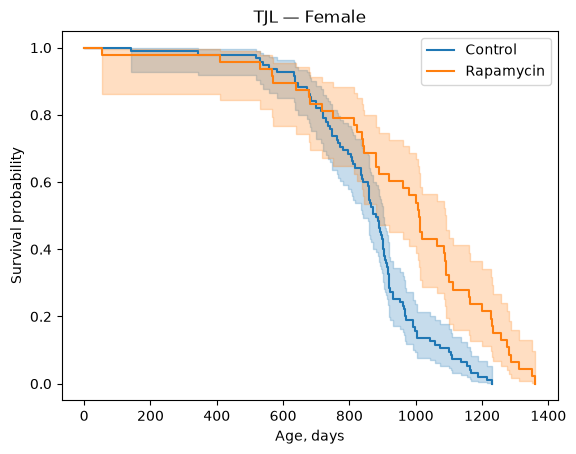

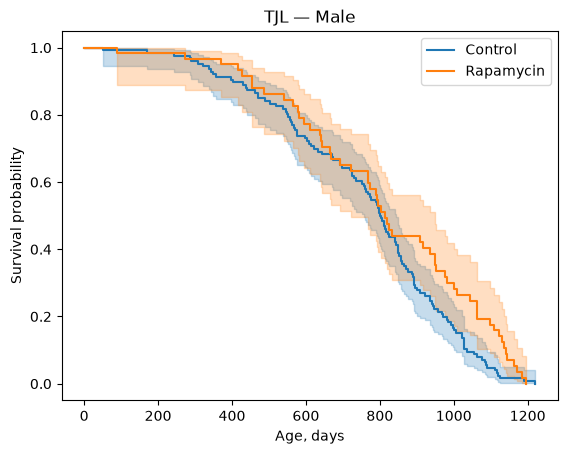

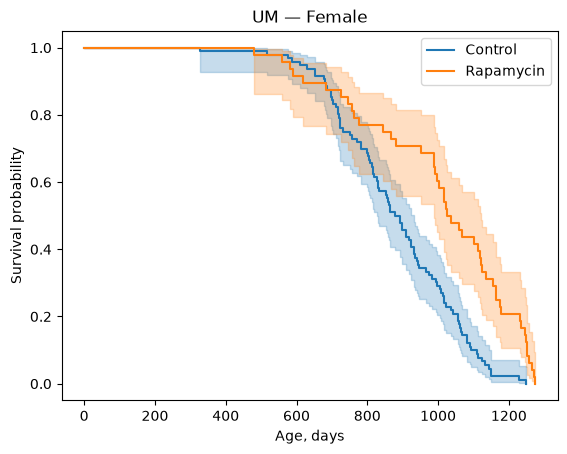

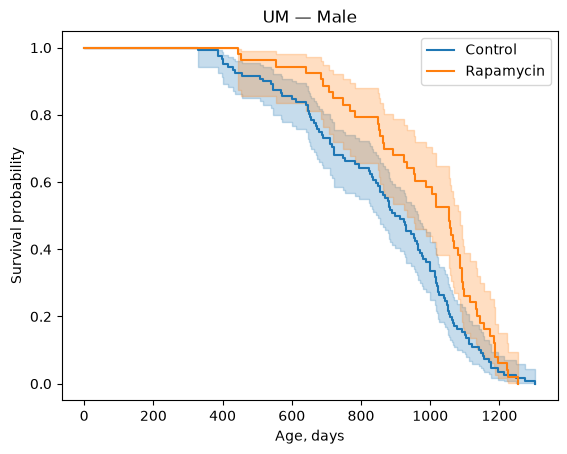

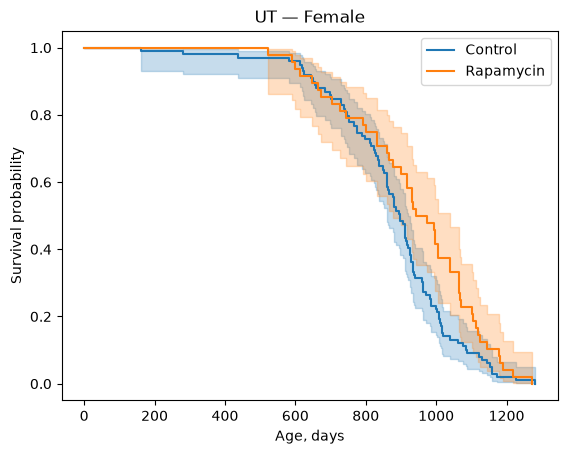

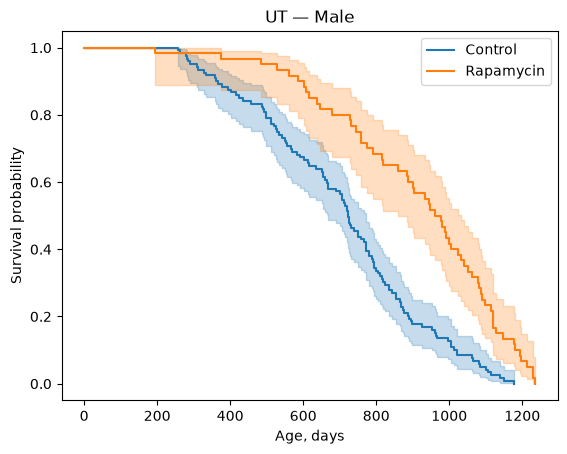

In [15]:
for site in sorted(study["site"].unique()):
    for sex, sex_label in [("f", "Female"), ("m", "Male")]:
        subset = study[
            (study["site"] == site)
            & (study["sex"] == sex)
        ]

        control = subset[subset["group"] == "Control"]
        rapa = subset[subset["group"] == "Rapa"]

        km_control = fit_km(control, "Control")
        km_rapa = fit_km(rapa, "Rapamycin")

        fig, ax = plt.subplots()
        km_control.plot_survival_function(ax=ax)
        km_rapa.plot_survival_function(ax=ax)

        ax.set(
            title=f"{site} — {sex_label}",
            xlabel="Age, days",
            ylabel="Survival probability",
        )
        plt.show()

## Wang–Allison late-life survival test

The ITP uses the Wang–Allison approach as a test of survival to exceptionally old ages.

For each `site × sex`:

1. combine Control and Rapa;
2. estimate the age where the joint survival curve reaches 10%;
3. classify animals as alive or dead at that threshold;
4. exclude animals censored before the threshold because their status is unknown;
5. pool the alive/dead counts across sites;
6. compare Control and Rapa with Fisher's exact test.

This is distinct from simply comparing the two groups' own p90 ages.

In [16]:
def wang_allison_site_counts(data):
    joint_km = KaplanMeierFitter().fit(
        durations=data["age"],
        event_observed=data["dead"],
    )

    threshold = float(
        qth_survival_time(
            0.10,
            joint_km.survival_function_,
        )
    )

    rows = []

    for group in ["Control", "Rapa"]:
        g = data[data["group"] == group]

        alive = (g["age"] >= threshold).sum()

        dead_before = (
            (g["dead"] == 1)
            & (g["age"] < threshold)
        ).sum()

        censored_before = (
            (g["dead"] == 0)
            & (g["age"] < threshold)
        ).sum()

        rows.append({
            "group": group,
            "threshold_age": threshold,
            "alive": int(alive),
            "dead": int(dead_before),
            "censored_before_threshold": int(censored_before),
        })

    return pd.DataFrame(rows)

In [17]:
wa_site_tables = []

for sex in ["f", "m"]:
    for site in sorted(study["site"].unique()):
        subset = study[
            (study["sex"] == sex)
            & (study["site"] == site)
        ]

        counts = wang_allison_site_counts(subset)
        counts.insert(0, "site", site)
        counts.insert(1, "sex", sex)
        wa_site_tables.append(counts)

wa_site_counts = pd.concat(
    wa_site_tables,
    ignore_index=True,
)

wa_site_counts

,site,sex,group,threshold_age,alive,dead,censored_before_threshold
0,TJL,f,Control,1168.0,4,91,1
1,TJL,f,Rapa,1168.0,11,36,1
2,UM,f,Control,1164.0,2,93,1
3,UM,f,Rapa,1164.0,13,35,0
4,UT,f,Control,1124.0,8,91,5
5,UT,f,Rapa,1124.0,7,41,0
6,TJL,m,Control,1088.0,8,118,0
7,TJL,m,Rapa,1088.0,11,46,3
8,UM,m,Control,1170.0,8,104,14
9,UM,m,Rapa,1170.0,8,43,6


In [18]:
wa_results = []

for sex in ["f", "m"]:
    x = wa_site_counts[wa_site_counts["sex"] == sex]

    pooled = (
        x.groupby("group")[["alive", "dead"]]
        .sum()
        .reindex(["Control", "Rapa"])
    )

    table = pooled[["alive", "dead"]].to_numpy()

    odds_ratio, p_value = fisher_exact(
        table,
        alternative="two-sided",
    )

    wa_results.append({
        "sex": sex,
        "control_alive": int(pooled.loc["Control", "alive"]),
        "control_dead": int(pooled.loc["Control", "dead"]),
        "rapa_alive": int(pooled.loc["Rapa", "alive"]),
        "rapa_dead": int(pooled.loc["Rapa", "dead"]),
        "odds_ratio": odds_ratio,
        "fisher_p": p_value,
    })

wang_allison_results = pd.DataFrame(wa_results)
wang_allison_results

,sex,control_alive,control_dead,rapa_alive,rapa_dead,odds_ratio,fisher_p
0,f,14,275,31,112,0.183930,3.303670e-07
1,m,20,337,33,135,0.242784,1.817369e-06


## Cox proportional hazards model

A Cox model estimates a hazard ratio:

\[
HR =
\frac{h_{Rapa}(t)}
     {h_{Control}(t)}.
\]

Interpretation:

- `HR = 1.0`: equal hazard;
- `HR = 0.8`: Rapa hazard is approximately 20% lower;
- `HR = 1.2`: Rapa hazard is approximately 20% higher.

Because the study was run at multiple sites, the Cox model is stratified by `site`. Each site receives its own baseline hazard while the Rapa coefficient is estimated across sites.

In [19]:
def fit_site_stratified_cox(data):
    cox_data = data[
        ["age", "dead", "site", "group"]
    ].copy()

    cox_data["rapa"] = (
        cox_data["group"] == "Rapa"
    ).astype(int)

    cph = CoxPHFitter()

    cph.fit(
        cox_data[
            ["age", "dead", "site", "rapa"]
        ],
        duration_col="age",
        event_col="dead",
        strata=["site"],
    )

    return cph, cox_data

In [20]:
cox_models = {}
cox_rows = []

for sex in ["f", "m"]:
    sex_data = study[study["sex"] == sex]

    cph, cox_data = fit_site_stratified_cox(sex_data)
    cox_models[sex] = (cph, cox_data)

    row = cph.summary.loc["rapa"]

    cox_rows.append({
        "sex": sex,
        "hazard_ratio": row["exp(coef)"],
        "hr_ci_lower_95": row["exp(coef) lower 95%"],
        "hr_ci_upper_95": row["exp(coef) upper 95%"],
        "p_value": row["p"],
    })

cox_results = pd.DataFrame(cox_rows)
cox_results

,sex,hazard_ratio,hr_ci_lower_95,hr_ci_upper_95,p_value
0,f,0.494067,0.397187,0.614576,2.427112e-10
1,m,0.565897,0.466786,0.686052,6.807120e-09


### Proportional-hazards assumption

The Cox model assumes that the treatment hazard ratio is approximately constant over time.

The diagnostic below checks that assumption separately by sex.

In [21]:
for sex in ["f", "m"]:
    cph, cox_data = cox_models[sex]

    print(f"\n--- sex={sex} ---")
    cph.check_assumptions(
        cox_data[
            ["age", "dead", "site", "rapa"]
        ],
        p_value_threshold=0.05,
        show_plots=False,
    )


--- sex=f ---
Proportional hazard assumption looks okay.

--- sex=m ---
The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'rapa' failed the non-proportional test: p-value is 0.0484.

   Advice: with so few unique values (only 2), you can include `strata=['rapa', ...]` in the call in
`.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



## Final result table

In [22]:
final_results = (
    lifespan_summary
    .merge(
        logrank_results.rename(
            columns={
                "test_statistic": "pooled_logrank_statistic",
                "p_value": "pooled_logrank_p",
            }
        ),
        on="sex",
    )
    .merge(
        wang_allison_results[
            ["sex", "odds_ratio", "fisher_p"]
        ].rename(
            columns={
                "odds_ratio": "wang_allison_odds_ratio",
                "fisher_p": "wang_allison_p",
            }
        ),
        on="sex",
    )
    .merge(
        cox_results.rename(
            columns={
                "p_value": "cox_p",
            }
        ),
        on="sex",
    )
)

final_results.round(4)

,sex,median_control,median_rapa,median_change_pct,p90_control,p90_rapa,p90_change_pct,pooled_logrank_statistic,pooled_logrank_p,wang_allison_odds_ratio,wang_allison_p,hazard_ratio,hr_ci_lower_95,hr_ci_upper_95,cox_p
0,f,886.0,1005.0,13.4312,1094.0,1249.0,14.1682,44.7494,0.0,0.1839,0.0,0.4941,0.3972,0.6146,0.0
1,m,797.0,952.0,19.4479,1078.0,1176.0,9.0909,30.8336,0.0,0.2428,0.0,0.5659,0.4668,0.6861,0.0


## Interpretation

The notebook now separates four different statistical questions:

| Quantity | Question |
|---|---|
| Kaplan–Meier curve | How does survival change with age? |
| Median / p90 age | How large is the descriptive lifespan shift? |
| Log-rank test | Do the complete survival curves differ? |
| Wang–Allison test | Does treatment improve survival to exceptionally old ages? |
| Site-stratified Cox HR | How does the estimated hazard differ after accounting for site-specific baseline hazards? |

These quantities are related but not interchangeable.

For example, an HR of `0.72` means the fitted instantaneous hazard is 72% of the Control hazard. It does **not** mean lifespan increased by 28%.

## References

Harrison DE, Strong R, Sharp ZD, et al. **Rapamycin fed late in life extends lifespan in genetically heterogeneous mice.** Nature. 2009;460:392–395.  
https://doi.org/10.1038/nature08221

Full text:  
https://pmc.ncbi.nlm.nih.gov/articles/PMC2786175/

NIA Interventions Testing Program data:  
https://phenome.jax.org/projects/ITP1

The analysis is an educational reproduction of mouse survival statistics. It does not provide clinical evidence for rapamycin use in humans.